In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from pathlib import Path
from statistics import mean
import matplotlib.pyplot as plt
import json
from scipy.interpolate import griddata

In [3]:
# ------------------------------- setting start ------------------------------ #
# color
color_palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
errorbar_color = "#3A3A3A"

# font
csfont = {'family':'Times New Roman', 'serif': 'Times' , 'size' : 23}
plt.rc('text', usetex=True)
plt.rc('font', **csfont)

# markers
markers=["o","*","^","D"]
linestyles = ['-', '--', '-.', ':']

# Ref: https://blog.csdn.net/Strive_For_Future/article/details/118755312

# bar plot size
bar_width = 0.4
bar_btw_space = 0.04
bar_space = 0.2

# errorbar plot size
err_lw=1.5
err_capsize=4
err_capthick=1.5

# set fig size
figsize=(6.4, 4.8)
# -------------------------------- setting end ------------------------------- #

In [4]:
base_output_dir=Path("/home/syjintw/Desktop/NUS/LapisGS-object-based-renderer/plotting/figs")
base_output_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
def gs_res_in_diff_dist_line_plot():
    saveDir = Path(".")/"figs"/f"gs_res_in_diff_dist"
    saveDir.mkdir(parents=True, exist_ok=True)
    
    scene_name = "lego"
    # scene_name = "materials"
    gs_res_list = [1, 2, 4, 8]
    # cam_dist_list = [1, 2, 4, 8]
    cam_dist_list = [1, 2, 3, 4, 5, 6, 7, 8]
    
    # Metrics: SSIM, PSNR, MASKED_PSNR, LPIPS, LOSS, MASKED_LOSS
    METRICS_LIST = ["SSIM", "MASKED_SSIM", 
                    "PSNR", "MASKED_PSNR", 
                    "LPIPS", 
                    "LOSS", "MASKED_LOSS",
                    "SSIM_std", "MASKED_SSIM_std", 
                    "PSNR_std", "MASKED_PSNR_std", 
                    "LPIPS_std", 
                    "LOSS_std", "MASKED_LOSS_std"
                    ]
    
    data_list = []
    
    for gs_res in gs_res_list:
        for cam_dist in cam_dist_list:
            if gs_res < cam_dist:
                render_factor = 1
            else:
                # Bash 的除法本身就是 int()，會自動捨去小數
                render_factor = gs_res // cam_dist
                
            file_path = Path(f"/home/syjintw/Desktop/NUS/lapisgs-output/{scene_name}/opacity")/f"{scene_name}_res{gs_res}"/f"results_ours_{cam_dist}x_factor{render_factor}.json"
            with open(file_path, "r") as f:
                data = json.load(f)
                
                # Iterate through items (handles cases where one file has multiple experiments)
                l = [scene_name, gs_res, render_factor, cam_dist]
                for METRICS_NAME in METRICS_LIST:
                    l.append(data["ours_30000"][METRICS_NAME])
                data_list.append(l)
    
    column_names = ["scene", "gs_res", "render_factor", "cam_dist"] + METRICS_LIST
    df = pd.DataFrame(data_list, columns=column_names)
    
    # Step 1: change to plotting format and filter
    df_plot = df.copy()
    # df_plot['encode_size'] = df_plot['encode_size'] * 8 / df_plot['numOf3DGS']
    # df_plot['alg'] = df_plot['alg'].replace(['draco'], 'DRACO')
    
    # df_plot['scene_name'] = df_plot['scene_name'].replace(['drjohnson'], 'DJ')
    # df_plot['scene_name'] = df_plot['scene_name'].replace(['playroom'], 'PR')
    # df_plot['scene_name'] = df_plot['scene_name'].replace(['train'], 'Train')
    # df_plot['scene_name'] = df_plot['scene_name'].replace(['truck'], 'Truck')
    
    # ---------------------------------------------------------------------------- #
    #                                   Plotting                                   #
    # ---------------------------------------------------------------------------- #
    
    # ----------------------------------- PSNR ----------------------------------- #
    x_name = 'cam_dist'
    y_name = 'PSNR'
    y_std_name = 'PSNR_std'
    hue_name = 'gs_res'

    hue_list = df_plot[hue_name].unique()
    
    plt.figure(figsize=figsize)
    
    # Plot each group (hue)
    for idx, hue_val in enumerate(hue_list):
        # Filter data for this group
        subset = df_plot[df_plot[hue_name] == hue_val].sort_values(x_name)
        
        x = subset[x_name]
        y = subset[y_name]
        y_std = subset[y_std_name]
        
        # Calculate 95% CI bounds (Mean +/- 1.96 * Std)
        yerr = 1.96 * y_std
        
        plt.errorbar(
            x, y, 
            yerr=yerr, 
            label=f'{hue_val}', # label for legend
            marker=markers[idx], markersize=10,
            linestyle=linestyles[idx], linewidth=4, 
            elinewidth=err_lw, capthick=err_capthick, capsize=err_capsize,  # Adds the little cross-bars at the ends
            color=color_palette[idx], alpha=1.0
        )
        
        
    # Formatting
    # plt.title(r'PSNR vs Distance by gs\_res (with 95\% CI)') # Usually, we don't write title for figures in papers
    plt.xlabel('Distance')
    plt.ylabel('Quality in PSNR (dB)')
    plt.legend(title='', loc='lower right', fontsize="20", ncol=2, markerscale=1)
    
    # plt.xlim(0, 10)
    # plt.xticks([0, 5, 10])
    plt.ylim(0, 55)
    plt.yticks([0, 10, 20, 30, 40, 50])
    
    # plt.grid(True, linestyle='--', alpha=0.6) # Personlly, don't like grid in paper figures
    plt.tight_layout()
    # plt.savefig(f'{saveDir}/compression_size_scene.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{saveDir}/compression_size_scene.eps', dpi=300, bbox_inches='tight')
    plt.show()

    # ---------------------------------- M-PSNR ---------------------------------- #
    x_name = 'cam_dist'
    y_name = 'MASKED_PSNR'
    y_std_name = 'MASKED_PSNR_std'
    hue_name = 'gs_res'

    hue_list = df_plot[hue_name].unique()
    
    plt.figure(figsize=figsize)
    
    # Plot each group (hue)
    for idx, hue_val in enumerate(hue_list):
        # Filter data for this group
        subset = df_plot[df_plot[hue_name] == hue_val].sort_values(x_name)
        
        x = subset[x_name]
        y = subset[y_name]
        y_std = subset[y_std_name]
        
        # Calculate 95% CI bounds (Mean +/- 1.96 * Std)
        yerr = 1.96 * y_std
        
        plt.errorbar(
            x, y, 
            yerr=yerr, 
            label=f'{hue_val}', # label for legend
            marker=markers[idx], markersize=10,
            linestyle=linestyles[idx], linewidth=4, 
            elinewidth=err_lw, capthick=err_capthick, capsize=err_capsize,  # Adds the little cross-bars at the ends
            color=color_palette[idx], alpha=1.0
        )
        
        
    # Formatting
    # plt.title(r'PSNR vs Distance by gs\_res (with 95\% CI)') # Usually, we don't write title for figures in papers
    plt.xlabel('Distance')
    plt.ylabel('Quality in M-PSNR (dB)')
    plt.legend(title='', loc='upper right', fontsize="20", ncol=2, markerscale=1)
    
    # plt.xlim(0, 10)
    # plt.xticks([0, 5, 10])
    plt.ylim(0, 45)
    plt.yticks([0, 10, 20, 30, 40])
    
    # plt.grid(True, linestyle='--', alpha=0.6) # Personlly, don't like grid in paper figures
    plt.tight_layout()
    # plt.savefig(f'{saveDir}/compression_size_scene.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{saveDir}/compression_size_scene.eps', dpi=300, bbox_inches='tight')
    plt.show()

    # ----------------------------------- SSIM ----------------------------------- #
    x_name = 'cam_dist'
    y_name = 'SSIM'
    y_std_name = 'SSIM_std'
    hue_name = 'gs_res'

    hue_list = df_plot[hue_name].unique()
    
    plt.figure(figsize=figsize)
    
    # Plot each group (hue)
    for idx, hue_val in enumerate(hue_list):
        # Filter data for this group
        subset = df_plot[df_plot[hue_name] == hue_val].sort_values(x_name)
        
        x = subset[x_name]
        y = subset[y_name]
        y_std = subset[y_std_name]
        
        # Calculate 95% CI bounds (Mean +/- 1.96 * Std)
        yerr = 1.96 * y_std
        
        plt.errorbar(
            x, y, 
            yerr=yerr, 
            label=f'{hue_val}', # label for legend
            marker=markers[idx], markersize=10,
            linestyle=linestyles[idx], linewidth=4, 
            elinewidth=err_lw, capthick=err_capthick, capsize=err_capsize,  # Adds the little cross-bars at the ends
            color=color_palette[idx], alpha=1.0
        )
        
        
    # Formatting
    # plt.title(r'PSNR vs Distance by gs\_res (with 95\% CI)') # Usually, we don't write title for figures in papers
    plt.xlabel('Distance')
    plt.ylabel('Quality in SSIM')
    plt.legend(title='', loc='lower right', fontsize="20", ncol=2, markerscale=1)
    
    # plt.xlim(0, 10)
    # plt.xticks([0, 5, 10])
    plt.ylim(0.78, 1.02)
    plt.yticks([0.8, 0.9, 1.0])
    
    # plt.grid(True, linestyle='--', alpha=0.6) # Personlly, don't like grid in paper figures
    plt.tight_layout()
    # plt.savefig(f'{saveDir}/compression_size_scene.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{saveDir}/compression_size_scene.eps', dpi=300, bbox_inches='tight')
    plt.show()
    
    # -------------------------------- MASKED_SSIM ------------------------------- #
    x_name = 'cam_dist'
    y_name = 'MASKED_SSIM'
    y_std_name = 'MASKED_SSIM_std'
    hue_name = 'gs_res'

    hue_list = df_plot[hue_name].unique()
    
    plt.figure(figsize=figsize)
    
    # Plot each group (hue)
    for idx, hue_val in enumerate(hue_list):
        # Filter data for this group
        subset = df_plot[df_plot[hue_name] == hue_val].sort_values(x_name)
        
        x = subset[x_name]
        y = subset[y_name]
        y_std = subset[y_std_name]
        
        # Calculate 95% CI bounds (Mean +/- 1.96 * Std)
        yerr = 1.96 * y_std
        
        plt.errorbar(
            x, y, 
            yerr=yerr, 
            label=f'{hue_val}', # label for legend
            marker=markers[idx], markersize=10,
            linestyle=linestyles[idx], linewidth=4, 
            elinewidth=err_lw, capthick=err_capthick, capsize=err_capsize,  # Adds the little cross-bars at the ends
            color=color_palette[idx], alpha=1.0
        )
        
        
    # Formatting
    # plt.title(r'PSNR vs Distance by gs\_res (with 95\% CI)') # Usually, we don't write title for figures in papers
    plt.xlabel('Distance')
    plt.ylabel('Quality in M-SSIM')
    plt.legend(title='', loc='lower right', fontsize="20", ncol=2, markerscale=1)
    
    # plt.xlim(0, 10)
    # plt.xticks([0, 5, 10])
    plt.ylim(0., 1.02)
    # plt.yticks([0.8, 0.9, 1.0])
    
    # plt.grid(True, linestyle='--', alpha=0.6) # Personlly, don't like grid in paper figures
    plt.tight_layout()
    # plt.savefig(f'{saveDir}/compression_size_scene.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{saveDir}/compression_size_scene.eps', dpi=300, bbox_inches='tight')
    plt.show()
    
gs_res_in_diff_dist_line_plot()

In [ ]:
def gs_res_in_diff_dist_bar_plot():
    saveDir = Path(".")/"figs"/f"gs_res_in_diff_dist_bar_plot"
    saveDir.mkdir(parents=True, exist_ok=True)
    
    scene_name = "lego"
    # scene_name = "materials"
    gs_res_list = [1, 2, 4, 8]
    cam_dist_list = [1, 2, 3, 4, 5, 6, 7, 8]
    # cam_dist_list = [1, 2, 4, 8]
    
    # Metrics: SSIM, PSNR, MASKED_PSNR, LPIPS, LOSS, MASKED_LOSS
    METRICS_LIST = ["SSIM", "MASKED_SSIM", 
                    "PSNR", "MASKED_PSNR", 
                    "LPIPS", 
                    "LOSS", "MASKED_LOSS",
                    "SSIM_std", "MASKED_SSIM_std", 
                    "PSNR_std", "MASKED_PSNR_std", 
                    "LPIPS_std", 
                    "LOSS_std", "MASKED_LOSS_std"
                    ]
    
    data_list = []
    
    for gs_res in gs_res_list:
        for cam_dist in cam_dist_list:
            if gs_res < cam_dist:
                render_factor = 1
            else:
                # Bash 的除法本身就是 int()，會自動捨去小數
                render_factor = gs_res // cam_dist
                
            # file_path = Path(f"/home/syjintw/Desktop/NUS/lapisgs-output/{scene_name}_old/opacity")/f"{scene_name}_res{gs_res}"/f"results_ours_{cam_dist}x_factor{render_factor}.json"
            file_path = Path(f"/home/syjintw/Desktop/NUS/lapisgs-output/{scene_name}/opacity")/f"{scene_name}_res{gs_res}"/f"results_ours_{cam_dist}x_factor{render_factor}.json"
            with open(file_path, "r") as f:
                data = json.load(f)
                
                # Iterate through items (handles cases where one file has multiple experiments)
                l = [scene_name, gs_res, render_factor, cam_dist]
                for METRICS_NAME in METRICS_LIST:
                    l.append(data["ours_30000"][METRICS_NAME])
                data_list.append(l)
    
    column_names = ["scene", "gs_res", "render_factor", "cam_dist"] + METRICS_LIST
    df = pd.DataFrame(data_list, columns=column_names)
    
    # Step 1: change to plotting format and filter
    df_plot = df.copy()
    # df_plot['encode_size'] = df_plot['encode_size'] * 8 / df_plot['numOf3DGS']
    # df_plot['alg'] = df_plot['alg'].replace(['draco'], 'DRACO')
    
    # df_plot['scene_name'] = df_plot['scene_name'].replace(['drjohnson'], 'DJ')
    # df_plot['scene_name'] = df_plot['scene_name'].replace(['playroom'], 'PR')
    # df_plot['scene_name'] = df_plot['scene_name'].replace(['train'], 'Train')
    # df_plot['scene_name'] = df_plot['scene_name'].replace(['truck'], 'Truck')
    
    # ---------------------------------------------------------------------------- #
    #                                   Plotting                                   #
    # ---------------------------------------------------------------------------- #
    plt.figure(figsize=figsize)

    # ----------------------------------- PSNR ----------------------------------- #
    x_name = 'cam_dist'
    y_name = 'PSNR'
    y_std_name = 'PSNR_std'
    hue_name = 'gs_res'

    x_list = sorted(df_plot['cam_dist'].unique())
    hue_list = sorted(df_plot[hue_name].unique())
    
    x_indexes = np.arange(len(x_list))  # Base positions [0, 1, 2, ...]
    n_groups = len(hue_list)
    # Define Bar Layout
    total_width = 0.85                # Total width of the group of bars
    bar_width = total_width / n_groups
 
    # Plot each group (hue)
    for idx, hue_val in enumerate(hue_list):
        # Filter data for this group
        subset = df_plot[df_plot[hue_name] == hue_val]
        
        # Align data to ensure correct order matches x_indexes
        # (reindexing ensures that if a dist is missing data, it handles it gracefully)
        subset = subset.set_index(x_name).reindex(x_list).reset_index()

        y = subset[y_name]
        y_std = subset[y_std_name]
        
        # Calculate 95% CI bounds (Mean +/- 1.96 * Std)
        yerr = 1.96 * y_std
        
        # Calculate X position offset
        # Centers the group of bars around the main tick
        offset = (idx - (n_groups - 1) / 2) * bar_width

        plt.bar(
            x_indexes + offset,      # X position
            y,                       # Height
            width=bar_width, 
            yerr=yerr,       # Error bars
            label=f'{hue_val}',
            capsize=2.0,
            color=color_palette[idx], alpha=1.0,
            # edgecolor='black' # Sharp edges
        )
        
    # Formatting
    # plt.title(r'PSNR vs Distance by gs\_res (with 95\% CI)') # Usually, we don't write title for figures in papers
    plt.xlabel('Distance')
    plt.ylabel('Quality in PSNR (dB)')
    plt.legend(title='', loc='lower right', fontsize="20", ncol=2, markerscale=1)
    
    # Set X-axis ticks to display the actual X values
    plt.xticks(x_indexes, x_list)
    plt.ylim(0, 55)
    plt.yticks([0, 10, 20, 30, 40, 50])
    
    # plt.grid(True, linestyle='--', alpha=0.6) # Personlly, don't like grid in paper figures
    plt.tight_layout()
    # plt.savefig(f'{saveDir}/compression_size_scene.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{saveDir}/compression_size_scene.eps', dpi=300, bbox_inches='tight')
    plt.show()

    # ---------------------------------- M-PSNR ---------------------------------- #
    x_name = 'cam_dist'
    y_name = 'MASKED_PSNR'
    y_std_name = 'MASKED_PSNR_std'
    hue_name = 'gs_res'

    x_list = sorted(df_plot['cam_dist'].unique())
    hue_list = sorted(df_plot[hue_name].unique())
    
    x_indexes = np.arange(len(x_list))  # Base positions [0, 1, 2, ...]
    n_groups = len(hue_list)
    # Define Bar Layout
    total_width = 0.85                # Total width of the group of bars
    bar_width = total_width / n_groups
 
    # Plot each group (hue)
    for idx, hue_val in enumerate(hue_list):
        # Filter data for this group
        subset = df_plot[df_plot[hue_name] == hue_val]
        
        # Align data to ensure correct order matches x_indexes
        # (reindexing ensures that if a dist is missing data, it handles it gracefully)
        subset = subset.set_index(x_name).reindex(x_list).reset_index()

        y = subset[y_name]
        y_std = subset[y_std_name]
        
        # Calculate 95% CI bounds (Mean +/- 1.96 * Std)
        yerr = 1.96 * y_std
        
        # Calculate X position offset
        # Centers the group of bars around the main tick
        offset = (idx - (n_groups - 1) / 2) * bar_width

        plt.bar(
            x_indexes + offset,      # X position
            y,                       # Height
            width=bar_width, 
            yerr=yerr,       # Error bars
            label=f'{hue_val}',
            capsize=2.0,
            color=color_palette[idx], alpha=1.0,
            # edgecolor='black' # Sharp edges
        )
        
    # Formatting
    # plt.title(r'PSNR vs Distance by gs\_res (with 95\% CI)') # Usually, we don't write title for figures in papers
    plt.xlabel('Distance')
    plt.ylabel('Quality in M-PSNR (dB)')
    plt.legend(title='', loc='upper right', fontsize="20", ncol=2, markerscale=1)
    
    # Set X-axis ticks to display the actual X values
    plt.xticks(x_indexes, x_list)
    plt.ylim(0, 45)
    plt.yticks([0, 10, 20, 30, 40])
    
    # plt.grid(True, linestyle='--', alpha=0.6) # Personlly, don't like grid in paper figures
    plt.tight_layout()
    # plt.savefig(f'{saveDir}/compression_size_scene.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{saveDir}/compression_size_scene.eps', dpi=300, bbox_inches='tight')
    plt.show()

    # ----------------------------------- SSIM ----------------------------------- #
    x_name = 'cam_dist'
    y_name = 'SSIM'
    y_std_name = 'SSIM_std'
    hue_name = 'gs_res'

    x_list = sorted(df_plot['cam_dist'].unique())
    hue_list = sorted(df_plot[hue_name].unique())
    
    x_indexes = np.arange(len(x_list))  # Base positions [0, 1, 2, ...]
    n_groups = len(hue_list)
    # Define Bar Layout
    total_width = 0.85                # Total width of the group of bars
    bar_width = total_width / n_groups
 
    # Plot each group (hue)
    for idx, hue_val in enumerate(hue_list):
        # Filter data for this group
        subset = df_plot[df_plot[hue_name] == hue_val]
        
        # Align data to ensure correct order matches x_indexes
        # (reindexing ensures that if a dist is missing data, it handles it gracefully)
        subset = subset.set_index(x_name).reindex(x_list).reset_index()

        y = subset[y_name]
        y_std = subset[y_std_name]
        
        # Calculate 95% CI bounds (Mean +/- 1.96 * Std)
        yerr = 1.96 * y_std
        
        # Calculate X position offset
        # Centers the group of bars around the main tick
        offset = (idx - (n_groups - 1) / 2) * bar_width

        plt.bar(
            x_indexes + offset,      # X position
            y,                       # Height
            width=bar_width, 
            yerr=yerr,       # Error bars
            label=f'{hue_val}',
            capsize=2.0,
            color=color_palette[idx], alpha=1.0,
            # edgecolor='black' # Sharp edges
        )
        
    # Formatting
    # plt.title(r'PSNR vs Distance by gs\_res (with 95\% CI)') # Usually, we don't write title for figures in papers
    plt.xlabel('Distance')
    plt.ylabel('Quality in SSIM')
    plt.legend(title='', loc='lower right', fontsize="20", ncol=2, markerscale=1)
    
    # Set X-axis ticks to display the actual X values
    plt.xticks(x_indexes, x_list)
    plt.ylim(0.78, 1.02)
    plt.yticks([0.8, 0.9, 1.0])
    
    # plt.grid(True, linestyle='--', alpha=0.6) # Personlly, don't like grid in paper figures
    plt.tight_layout()
    # plt.savefig(f'{saveDir}/compression_size_scene.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{saveDir}/compression_size_scene.eps', dpi=300, bbox_inches='tight')
    plt.show()

    # -------------------------------- MASKED_SSIM ------------------------------- #
    x_name = 'cam_dist'
    y_name = 'MASKED_SSIM'
    y_std_name = 'MASKED_SSIM_std'
    hue_name = 'gs_res'

    x_list = sorted(df_plot['cam_dist'].unique())
    hue_list = sorted(df_plot[hue_name].unique())
    
    x_indexes = np.arange(len(x_list))  # Base positions [0, 1, 2, ...]
    n_groups = len(hue_list)
    # Define Bar Layout
    total_width = 0.85                # Total width of the group of bars
    bar_width = total_width / n_groups
 
    # Plot each group (hue)
    for idx, hue_val in enumerate(hue_list):
        # Filter data for this group
        subset = df_plot[df_plot[hue_name] == hue_val]
        
        # Align data to ensure correct order matches x_indexes
        # (reindexing ensures that if a dist is missing data, it handles it gracefully)
        subset = subset.set_index(x_name).reindex(x_list).reset_index()

        y = subset[y_name]
        y_std = subset[y_std_name]
        
        # Calculate 95% CI bounds (Mean +/- 1.96 * Std)
        yerr = 1.96 * y_std
        
        # Calculate X position offset
        # Centers the group of bars around the main tick
        offset = (idx - (n_groups - 1) / 2) * bar_width

        plt.bar(
            x_indexes + offset,      # X position
            y,                       # Height
            width=bar_width, 
            yerr=yerr,       # Error bars
            label=f'{hue_val}',
            capsize=2.0,
            color=color_palette[idx], alpha=1.0,
            # edgecolor='black' # Sharp edges
        )
        
    # Formatting
    # plt.title(r'PSNR vs Distance by gs\_res (with 95\% CI)') # Usually, we don't write title for figures in papers
    plt.xlabel('Distance')
    plt.ylabel('Quality in M-SSIM')
    plt.legend(title='', loc='lower right', fontsize="20", ncol=2, markerscale=1)
    
    # Set X-axis ticks to display the actual X values
    plt.xticks(x_indexes, x_list)
    plt.ylim(0, 1.02)
    # plt.yticks([0.8, 0.9, 1.0])
    
    # plt.grid(True, linestyle='--', alpha=0.6) # Personlly, don't like grid in paper figures
    plt.tight_layout()
    # plt.savefig(f'{saveDir}/compression_size_scene.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{saveDir}/compression_size_scene.eps', dpi=300, bbox_inches='tight')
    plt.show()


    # ----------------------------------- LOSS ----------------------------------- #
    x_name = 'cam_dist'
    y_name = 'LOSS'
    y_std_name = 'LOSS_std'
    hue_name = 'gs_res'

    x_list = sorted(df_plot['cam_dist'].unique())
    hue_list = sorted(df_plot[hue_name].unique())
    
    x_indexes = np.arange(len(x_list))  # Base positions [0, 1, 2, ...]
    n_groups = len(hue_list)
    # Define Bar Layout
    total_width = 0.85                # Total width of the group of bars
    bar_width = total_width / n_groups
 
    # Plot each group (hue)
    for idx, hue_val in enumerate(hue_list):
        # Filter data for this group
        subset = df_plot[df_plot[hue_name] == hue_val]
        
        # Align data to ensure correct order matches x_indexes
        # (reindexing ensures that if a dist is missing data, it handles it gracefully)
        subset = subset.set_index(x_name).reindex(x_list).reset_index()

        y = subset[y_name]
        y_std = subset[y_std_name]
        
        # Calculate 95% CI bounds (Mean +/- 1.96 * Std)
        yerr = 1.96 * y_std
        
        # Calculate X position offset
        # Centers the group of bars around the main tick
        offset = (idx - (n_groups - 1) / 2) * bar_width

        plt.bar(
            x_indexes + offset,      # X position
            y,                       # Height
            width=bar_width, 
            yerr=yerr,       # Error bars
            label=f'{hue_val}',
            capsize=2.0,
            color=color_palette[idx], alpha=1.0,
            # edgecolor='black' # Sharp edges
        )
        
    # Formatting
    # plt.title(r'PSNR vs Distance by gs\_res (with 95\% CI)') # Usually, we don't write title for figures in papers
    plt.xlabel('Distance')
    plt.ylabel('Quality in LOSS')
    plt.legend(title='', loc='upper right', fontsize="20", ncol=2, markerscale=1)
    
    # Set X-axis ticks to display the actual X values
    plt.xticks(x_indexes, x_list)
    plt.ylim(0.0, 0.1)
    plt.yticks([0.0, 0.05, 0.1])
    
    # plt.grid(True, linestyle='--', alpha=0.6) # Personlly, don't like grid in paper figures
    plt.tight_layout()
    # plt.savefig(f'{saveDir}/compression_size_scene.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{saveDir}/compression_size_scene.eps', dpi=300, bbox_inches='tight')
    plt.show()

    # -------------------------------- MASKED_LOSS ------------------------------- #
    x_name = 'cam_dist'
    y_name = 'MASKED_LOSS'
    y_std_name = 'MASKED_LOSS_std'
    hue_name = 'gs_res'

    x_list = sorted(df_plot['cam_dist'].unique())
    hue_list = sorted(df_plot[hue_name].unique())
    
    x_indexes = np.arange(len(x_list))  # Base positions [0, 1, 2, ...]
    n_groups = len(hue_list)
    # Define Bar Layout
    total_width = 0.85                # Total width of the group of bars
    bar_width = total_width / n_groups
 
    # Plot each group (hue)
    for idx, hue_val in enumerate(hue_list):
        # Filter data for this group
        subset = df_plot[df_plot[hue_name] == hue_val]
        
        # Align data to ensure correct order matches x_indexes
        # (reindexing ensures that if a dist is missing data, it handles it gracefully)
        subset = subset.set_index(x_name).reindex(x_list).reset_index()

        y = subset[y_name]
        y_std = subset[y_std_name]
        
        # Calculate 95% CI bounds (Mean +/- 1.96 * Std)
        yerr = 1.96 * y_std
        
        # Calculate X position offset
        # Centers the group of bars around the main tick
        offset = (idx - (n_groups - 1) / 2) * bar_width

        plt.bar(
            x_indexes + offset,      # X position
            y,                       # Height
            width=bar_width, 
            yerr=yerr,       # Error bars
            label=f'{hue_val}',
            capsize=2.0,
            color=color_palette[idx], alpha=1.0,
            # edgecolor='black' # Sharp edges
        )
        
    # Formatting
    # plt.title(r'PSNR vs Distance by gs\_res (with 95\% CI)') # Usually, we don't write title for figures in papers
    plt.xlabel('Distance')
    plt.ylabel('Quality in M-LOSS')
    plt.legend(title='', loc='upper left', fontsize="20", ncol=2, markerscale=1)
    
    # Set X-axis ticks to display the actual X values
    plt.xticks(x_indexes, x_list)
    plt.ylim(0.0, 0.2)
    plt.yticks([0.0, 0.05, 0.1, 0.15, 0.2])
    
    # plt.grid(True, linestyle='--', alpha=0.6) # Personlly, don't like grid in paper figures
    plt.tight_layout()
    # plt.savefig(f'{saveDir}/compression_size_scene.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{saveDir}/compression_size_scene.eps', dpi=300, bbox_inches='tight')
    plt.show()

gs_res_in_diff_dist_bar_plot()

[['lego', 31, 1, 1, 8, 0.9960152506828308, 0.3761459290981293, 37.8852424621582, 14.498584747314453, -1.0, 0.0012457766570150852, 0.10062235593795776], ['lego', 6, 1, 1, 8, 0.9954466223716736, 0.41234636306762695, 35.80744171142578, 13.69895076751709, -1.0, 0.0015452818479388952, 0.10508081316947937], ['lego', 36, 1, 1, 8, 0.9972382187843323, 0.5417426824569702, 37.96211624145508, 14.339664459228516, -1.0, 0.0009511651005595922, 0.09260078519582748], ['lego', 19, 1, 1, 8, 0.9957243800163269, 0.3762872517108917, 35.02213668823242, 11.805871963500977, -1.0, 0.0015140946488827467, 0.14048978686332703], ['lego', 46, 1, 1, 8, 0.9960604310035706, 0.4901905059814453, 35.60772705078125, 13.325468063354492, -1.0, 0.001428255345672369, 0.10975416004657745], ['lego', 7, 1, 1, 8, 0.9956923127174377, 0.43992650508880615, 35.97294235229492, 13.789199829101562, -1.0, 0.0014698267914354801, 0.10161649435758591], ['lego', 39, 1, 1, 8, 0.9970739483833313, 0.5410963892936707, 36.82106399536133, 13.554984

<Figure size 640x480 with 0 Axes>

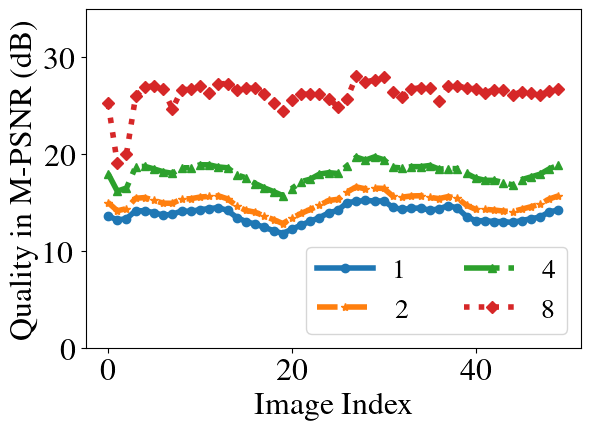

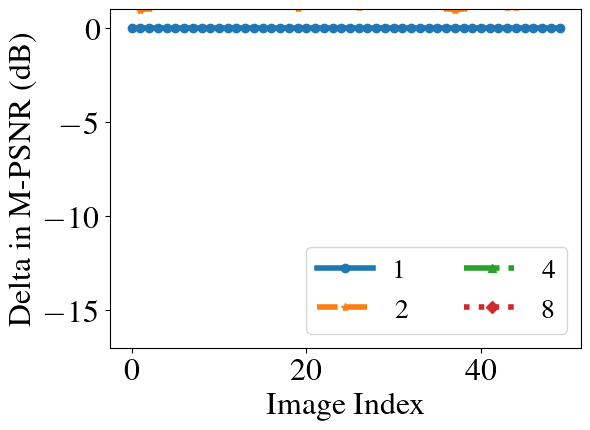

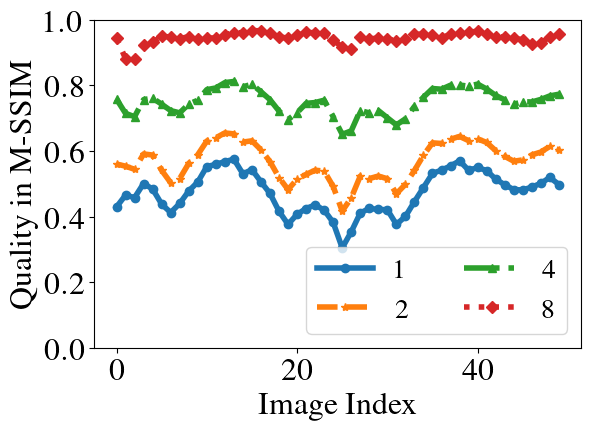

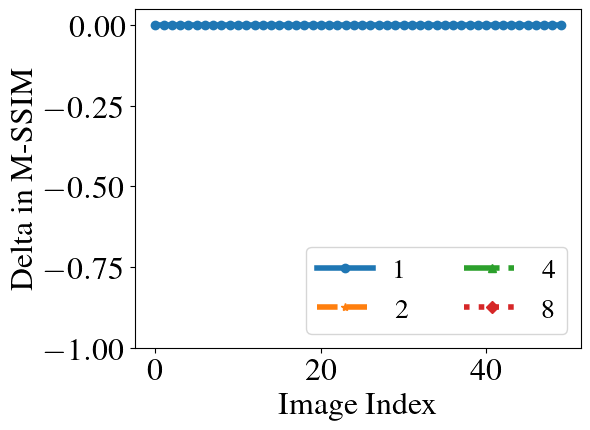

In [13]:
def gs_res_in_diff_cam_idx():
    saveDir = Path(".")/"figs"/f"gs_res_in_diff_cam_idx_bar_plot"
    saveDir.mkdir(parents=True, exist_ok=True)
    
    scene_name = "lego"
    # scene_name = "materials"
    gs_res_list = [1, 2, 4, 8]
    cam_dist_list = [8]
    # cam_dist_list = [1, 2, 4, 8]
    exp_name = "diff_dist"
    
    # Metrics: SSIM, PSNR, MASKED_PSNR, LPIPS, LOSS, MASKED_LOSS
    METRICS_LIST = ["SSIM", "MASKED_SSIM", 
                    "PSNR", "MASKED_PSNR", 
                    "LPIPS", 
                    "LOSS", "MASKED_LOSS",
                    ]
    
    data_list = []
    
    for gs_res in gs_res_list:
        for cam_dist in cam_dist_list:
            if gs_res < cam_dist:
                render_factor = 1
            else:
                # Bash 的除法本身就是 int()，會自動捨去小數
                render_factor = gs_res // cam_dist
                
            # file_path = Path(f"/home/syjintw/Desktop/NUS/lapisgs-output/{scene_name}_old/opacity")/f"{scene_name}_res{gs_res}"/f"results_ours_{cam_dist}x_factor{render_factor}.json"
            file_path = Path(f"/home/syjintw/Desktop/NUS/lapisgs-output/{scene_name}/opacity")/f"{scene_name}_res{gs_res}"/f"results_{exp_name}"/f"per_view_ours_{cam_dist}x_factor{render_factor}.json"
            with open(file_path, "r") as f:
                data = json.load(f)
                
                for image_name in data["ours_30000"]["SSIM"].keys():
                    # Iterate through items (handles cases where one file has multiple experiments)
                    l = [scene_name, int(image_name.split(".")[0]), gs_res, render_factor, cam_dist]
                    for METRICS_NAME in METRICS_LIST:
                        l.append(data["ours_30000"][METRICS_NAME][image_name])
                    data_list.append(l)
    print(data_list)
    column_names = ["scene", "image_idx", "gs_res", "render_factor", "cam_dist"] + METRICS_LIST
    df = pd.DataFrame(data_list, columns=column_names)
    
    # Step 1: change to plotting format and filter
    df_plot = df.copy()
    # df_plot['encode_size'] = df_plot['encode_size'] * 8 / df_plot['numOf3DGS']
    # df_plot['alg'] = df_plot['alg'].replace(['draco'], 'DRACO')
    
    # df_plot['scene_name'] = df_plot['scene_name'].replace(['drjohnson'], 'DJ')
    # df_plot['scene_name'] = df_plot['scene_name'].replace(['playroom'], 'PR')
    # df_plot['scene_name'] = df_plot['scene_name'].replace(['train'], 'Train')
    # df_plot['scene_name'] = df_plot['scene_name'].replace(['truck'], 'Truck')
    
    # ---------------------------------------------------------------------------- #
    #                                   Plotting                                   #
    # ---------------------------------------------------------------------------- #
    plt.figure(figsize=figsize)

    # -------------------------------- MASKED_PSNR ------------------------------- #
    x_name = 'image_idx'
    y_name = 'MASKED_PSNR'
    hue_name = 'gs_res'

    hue_list = df_plot[hue_name].unique()
    
    plt.figure(figsize=figsize)
    
    # Plot each group (hue)
    for idx, hue_val in enumerate(hue_list):
        # Filter data for this group
        subset = df_plot[df_plot[hue_name] == hue_val].sort_values(x_name)
        
        x = subset[x_name]
        y = subset[y_name]
        
        # # Calculate 95% CI bounds (Mean +/- 1.96 * Std)
        # yerr = 1.96 * y_std
        
        plt.errorbar(
            x, y, 
            yerr=None, 
            label=f'{hue_val}', # label for legend
            marker=markers[idx], markersize=6,
            linestyle=linestyles[idx], linewidth=4, 
            elinewidth=err_lw, capthick=err_capthick, capsize=err_capsize,  # Adds the little cross-bars at the ends
            color=color_palette[idx], alpha=1.0
        )
    
    # Formatting
    # plt.title(r'PSNR vs Distance by gs\_res (with 95\% CI)') # Usually, we don't write title for figures in papers
    plt.xlabel('Image Index')
    plt.ylabel('Quality in M-PSNR (dB)')
    plt.legend(title='', loc='lower right', fontsize="20", ncol=2, markerscale=1)
    
    # plt.xlim(0, 10)
    # plt.xticks([0, 5, 10])
    plt.ylim(0, 35)
    # plt.yticks([0, 10, 20, 30, 40, 50])
    
    # plt.grid(True, linestyle='--', alpha=0.6) # Personlly, don't like grid in paper figures
    plt.tight_layout()
    # plt.savefig(f'{saveDir}/compression_size_scene.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{saveDir}/compression_size_scene.eps', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ----------------------------- DIFF MASKED_PSNR ----------------------------- #
    x_name = 'image_idx'
    y_name = 'MASKED_PSNR'
    hue_name = 'gs_res'

    hue_list = df_plot[hue_name].unique()
    
    base_data = df_plot[df_plot[hue_name] == hue_list[0]].sort_values(x_name)
    
    plt.figure(figsize=figsize)
    
    # Plot each group (hue)
    for idx, hue_val in enumerate(hue_list):
        # Filter data for this group
        subset = df_plot[df_plot[hue_name] == hue_val].sort_values(x_name)
        
        x = subset[x_name]
        # y = subset[y_name]
        current_y = subset[y_name].values
        base_y = base_data[y_name].values
        y = (current_y - base_y) # Delta PSNR
        
        # # Calculate 95% CI bounds (Mean +/- 1.96 * Std)
        # yerr = 1.96 * y_std
        
        plt.errorbar(
            x, y, 
            yerr=None, 
            label=f'{hue_val}', # label for legend
            marker=markers[idx], markersize=6,
            linestyle=linestyles[idx], linewidth=4, 
            elinewidth=err_lw, capthick=err_capthick, capsize=err_capsize,  # Adds the little cross-bars at the ends
            color=color_palette[idx], alpha=1.0
        )
    
    # Formatting
    # plt.title(r'PSNR vs Distance by gs\_res (with 95\% CI)') # Usually, we don't write title for figures in papers
    plt.xlabel('Image Index')
    plt.ylabel('Delta in M-PSNR (dB)')
    plt.legend(title='', loc='lower right', fontsize="20", ncol=2, markerscale=1)
    
    # plt.xlim(0, 10)
    # plt.xticks([0, 5, 10])
    plt.ylim(-17, 1)
    # plt.yticks([0, 10, 20, 30, 40, 50])
    
    # plt.grid(True, linestyle='--', alpha=0.6) # Personlly, don't like grid in paper figures
    plt.tight_layout()
    # plt.savefig(f'{saveDir}/compression_size_scene.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{saveDir}/compression_size_scene.eps', dpi=300, bbox_inches='tight')
    plt.show()
    
    # -------------------------------- MASKED_SSIM ------------------------------- #
    x_name = 'image_idx'
    y_name = 'MASKED_SSIM'
    hue_name = 'gs_res'

    hue_list = df_plot[hue_name].unique()
    
    plt.figure(figsize=figsize)
    
    # Plot each group (hue)
    for idx, hue_val in enumerate(hue_list):
        # Filter data for this group
        subset = df_plot[df_plot[hue_name] == hue_val].sort_values(x_name)
        
        x = subset[x_name]
        y = subset[y_name]
        
        # # Calculate 95% CI bounds (Mean +/- 1.96 * Std)
        # yerr = 1.96 * y_std
        
        plt.errorbar(
            x, y, 
            yerr=None, 
            label=f'{hue_val}', # label for legend
            marker=markers[idx], markersize=6,
            linestyle=linestyles[idx], linewidth=4, 
            elinewidth=err_lw, capthick=err_capthick, capsize=err_capsize,  # Adds the little cross-bars at the ends
            color=color_palette[idx], alpha=1.0
        )
    
    # Formatting
    # plt.title(r'PSNR vs Distance by gs\_res (with 95\% CI)') # Usually, we don't write title for figures in papers
    plt.xlabel('Image Index')
    plt.ylabel('Quality in M-SSIM')
    plt.legend(title='', loc='lower right', fontsize="20", ncol=2, markerscale=1)
    
    # plt.xlim(0, 10)
    # plt.xticks([0, 5, 10])
    plt.ylim(0, 1)
    # plt.yticks([0, 10, 20, 30, 40, 50])
    
    # plt.grid(True, linestyle='--', alpha=0.6) # Personlly, don't like grid in paper figures
    plt.tight_layout()
    # plt.savefig(f'{saveDir}/compression_size_scene.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{saveDir}/compression_size_scene.eps', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ----------------------------- DIFF MASKED_SSIM ----------------------------- #
    x_name = 'image_idx'
    y_name = 'MASKED_SSIM'
    hue_name = 'gs_res'

    hue_list = df_plot[hue_name].unique()
    
    base_data = df_plot[df_plot[hue_name] == hue_list[0]].sort_values(x_name)
    
    plt.figure(figsize=figsize)
    
    # Plot each group (hue)
    for idx, hue_val in enumerate(hue_list):
        # Filter data for this group
        subset = df_plot[df_plot[hue_name] == hue_val].sort_values(x_name)
        
        x = subset[x_name]
        # y = subset[y_name]
        current_y = subset[y_name].values
        base_y = base_data[y_name].values
        y = (current_y - base_y) # Delta PSNR
        
        # # Calculate 95% CI bounds (Mean +/- 1.96 * Std)
        # yerr = 1.96 * y_std
        
        plt.errorbar(
            x, y, 
            yerr=None, 
            label=f'{hue_val}', # label for legend
            marker=markers[idx], markersize=6,
            linestyle=linestyles[idx], linewidth=4, 
            elinewidth=err_lw, capthick=err_capthick, capsize=err_capsize,  # Adds the little cross-bars at the ends
            color=color_palette[idx], alpha=1.0
        )
    
    # Formatting
    # plt.title(r'PSNR vs Distance by gs\_res (with 95\% CI)') # Usually, we don't write title for figures in papers
    plt.xlabel('Image Index')
    plt.ylabel('Delta in M-SSIM')
    plt.legend(title='', loc='lower right', fontsize="20", ncol=2, markerscale=1)
    
    # plt.xlim(0, 10)
    # plt.xticks([0, 5, 10])
    plt.ylim(-1, 0.05)
    # plt.yticks([0, 10, 20, 30, 40, 50])
    
    # plt.grid(True, linestyle='--', alpha=0.6) # Personlly, don't like grid in paper figures
    plt.tight_layout()
    # plt.savefig(f'{saveDir}/compression_size_scene.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{saveDir}/compression_size_scene.eps', dpi=300, bbox_inches='tight')
    plt.show()
    

gs_res_in_diff_cam_idx()

[['lego', 31, 2, 2, 1, 0.9833353757858276, 0.9397058486938477, 36.960330963134766, 31.097885131835938, -1.0, 0.006861717440187931, 0.016913576051592827], ['lego', 6, 2, 2, 1, 0.9802917838096619, 0.9480659365653992, 35.49220275878906, 31.075069427490234, -1.0, 0.008984929881989956, 0.017836695536971092], ['lego', 36, 2, 2, 1, 0.9833100438117981, 0.9449323415756226, 36.6146240234375, 31.23711395263672, -1.0, 0.007281901314854622, 0.016918402165174484], ['lego', 19, 2, 2, 1, 0.9796684980392456, 0.930141270160675, 34.887413024902344, 29.2574520111084, -1.0, 0.008891640231013298, 0.021647538989782333], ['lego', 46, 2, 2, 1, 0.9805377721786499, 0.9474135041236877, 35.24066925048828, 30.703094482421875, -1.0, 0.008986208587884903, 0.01831008866429329], ['lego', 7, 2, 2, 1, 0.9800052046775818, 0.9484158158302307, 35.38298034667969, 31.05951499938965, -1.0, 0.009167172014713287, 0.017936144024133682], ['lego', 39, 2, 2, 1, 0.982458233833313, 0.9464274644851685, 36.68524169921875, 31.63493919372

<Figure size 640x480 with 0 Axes>

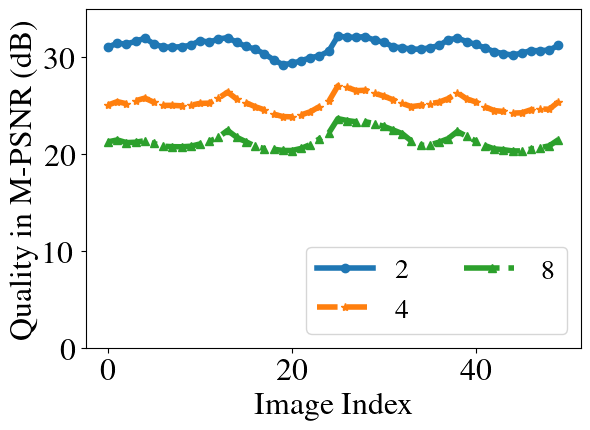

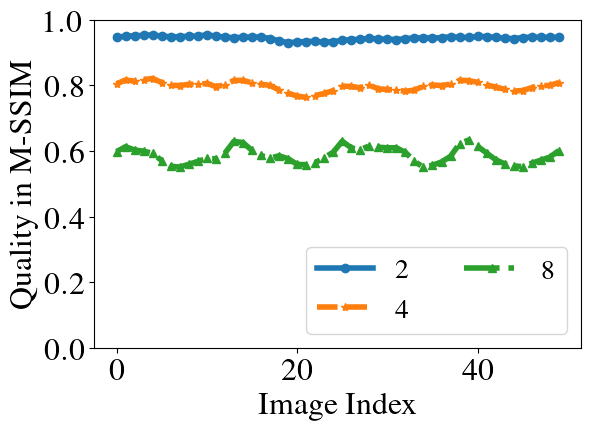

In [5]:
def gs_res_in_diff_cam_idx_distortion():
    # saveDir = Path(".")/"figs"/f"gs_res_in_diff_cam_idx_distortion_bar_plot"
    # saveDir.mkdir(parents=True, exist_ok=True)
    
    scene_name = "lego"
    exp_name = "diff_dist_distortion"
    gs_res_list = [2, 4, 8]
    cam_dist_list = [1]
    # cam_dist_list = [1, 2, 4, 8]
    
    # Metrics: SSIM, PSNR, MASKED_PSNR, LPIPS, LOSS, MASKED_LOSS
    METRICS_LIST = ["SSIM", "MASKED_SSIM", 
                    "PSNR", "MASKED_PSNR", 
                    "LPIPS", 
                    "LOSS", "MASKED_LOSS",
                    ]
    
    data_list = []
    
    for gs_res in gs_res_list:
        for cam_dist in cam_dist_list:
            if gs_res < cam_dist:
                render_factor = 1
            else:
                # Bash 的除法本身就是 int()，會自動捨去小數
                render_factor = gs_res // cam_dist
                
            # file_path = Path(f"/home/syjintw/Desktop/NUS/lapisgs-output/{scene_name}_old/opacity")/f"{scene_name}_res{gs_res}"/f"results_ours_{cam_dist}x_factor{render_factor}.json"
            file_path = Path(f"/home/syjintw/Desktop/NUS/lapisgs-output/{scene_name}/opacity")/f"{scene_name}_res{gs_res}"/f"results_{exp_name}"/f"per_view_ours_{cam_dist}x_factor{render_factor}.json"
            with open(file_path, "r") as f:
                data = json.load(f)
                
                for image_name in data["ours_30000"]["SSIM"].keys():
                    # Iterate through items (handles cases where one file has multiple experiments)
                    l = [scene_name, int(image_name.split(".")[0]), gs_res, render_factor, cam_dist]
                    for METRICS_NAME in METRICS_LIST:
                        l.append(data["ours_30000"][METRICS_NAME][image_name])
                    data_list.append(l)
    print(data_list)
    column_names = ["scene", "image_idx", "gs_res", "render_factor", "cam_dist"] + METRICS_LIST
    df = pd.DataFrame(data_list, columns=column_names)
    
    # Step 1: change to plotting format and filter
    df_plot = df.copy()
    # df_plot['encode_size'] = df_plot['encode_size'] * 8 / df_plot['numOf3DGS']
    # df_plot['alg'] = df_plot['alg'].replace(['draco'], 'DRACO')
    
    # df_plot['scene_name'] = df_plot['scene_name'].replace(['drjohnson'], 'DJ')
    # df_plot['scene_name'] = df_plot['scene_name'].replace(['playroom'], 'PR')
    # df_plot['scene_name'] = df_plot['scene_name'].replace(['train'], 'Train')
    # df_plot['scene_name'] = df_plot['scene_name'].replace(['truck'], 'Truck')
    
    # ---------------------------------------------------------------------------- #
    #                                   Plotting                                   #
    # ---------------------------------------------------------------------------- #
    plt.figure(figsize=figsize)

    # -------------------------------- MASKED_PSNR ------------------------------- #
    x_name = 'image_idx'
    y_name = 'MASKED_PSNR'
    hue_name = 'gs_res'

    hue_list = df_plot[hue_name].unique()
    
    plt.figure(figsize=figsize)
    
    # Plot each group (hue)
    for idx, hue_val in enumerate(hue_list):
        # Filter data for this group
        subset = df_plot[df_plot[hue_name] == hue_val].sort_values(x_name)
        
        x = subset[x_name]
        y = subset[y_name]
        
        # # Calculate 95% CI bounds (Mean +/- 1.96 * Std)
        # yerr = 1.96 * y_std
        
        plt.errorbar(
            x, y, 
            yerr=None, 
            label=f'{hue_val}', # label for legend
            marker=markers[idx], markersize=6,
            linestyle=linestyles[idx], linewidth=4, 
            elinewidth=err_lw, capthick=err_capthick, capsize=err_capsize,  # Adds the little cross-bars at the ends
            color=color_palette[idx], alpha=1.0
        )
    
    # Formatting
    # plt.title(r'PSNR vs Distance by gs\_res (with 95\% CI)') # Usually, we don't write title for figures in papers
    plt.xlabel('Image Index')
    plt.ylabel('Quality in M-PSNR (dB)')
    plt.legend(title='', loc='lower right', fontsize="20", ncol=2, markerscale=1)
    
    # plt.xlim(0, 10)
    # plt.xticks([0, 5, 10])
    plt.ylim(0, 35)
    # plt.yticks([0, 10, 20, 30, 40, 50])
    
    # plt.grid(True, linestyle='--', alpha=0.6) # Personlly, don't like grid in paper figures
    plt.tight_layout()
    # plt.savefig(f'{saveDir}/compression_size_scene.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{saveDir}/compression_size_scene.eps', dpi=300, bbox_inches='tight')
    plt.show()
    
    
    # -------------------------------- MASKED_SSIM ------------------------------- #
    x_name = 'image_idx'
    y_name = 'MASKED_SSIM'
    hue_name = 'gs_res'

    hue_list = df_plot[hue_name].unique()
    
    plt.figure(figsize=figsize)
    
    # Plot each group (hue)
    for idx, hue_val in enumerate(hue_list):
        # Filter data for this group
        subset = df_plot[df_plot[hue_name] == hue_val].sort_values(x_name)
        
        x = subset[x_name]
        y = subset[y_name]
        
        # # Calculate 95% CI bounds (Mean +/- 1.96 * Std)
        # yerr = 1.96 * y_std
        
        plt.errorbar(
            x, y, 
            yerr=None, 
            label=f'{hue_val}', # label for legend
            marker=markers[idx], markersize=6,
            linestyle=linestyles[idx], linewidth=4, 
            elinewidth=err_lw, capthick=err_capthick, capsize=err_capsize,  # Adds the little cross-bars at the ends
            color=color_palette[idx], alpha=1.0
        )
    
    # Formatting
    # plt.title(r'PSNR vs Distance by gs\_res (with 95\% CI)') # Usually, we don't write title for figures in papers
    plt.xlabel('Image Index')
    plt.ylabel('Quality in M-SSIM')
    plt.legend(title='', loc='lower right', fontsize="20", ncol=2, markerscale=1)
    
    # plt.xlim(0, 10)
    # plt.xticks([0, 5, 10])
    plt.ylim(0, 1)
    # plt.yticks([0, 10, 20, 30, 40, 50])
    
    # plt.grid(True, linestyle='--', alpha=0.6) # Personlly, don't like grid in paper figures
    plt.tight_layout()
    # plt.savefig(f'{saveDir}/compression_size_scene.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{saveDir}/compression_size_scene.eps', dpi=300, bbox_inches='tight')
    plt.show()
    

gs_res_in_diff_cam_idx_distortion()

[['lego', 31, 2, 2, 1, 0.9822348952293396, 0.9503547549247742, 36.14311218261719, 31.56215476989746, -1.0, 0.007550777867436409, 0.015018293634057045], ['lego', 6, 2, 2, 1, 0.9793813228607178, 0.9478111863136292, 35.64842987060547, 31.58026885986328, -1.0, 0.008848261088132858, 0.016175517812371254], ['lego', 36, 2, 2, 1, 0.9804286360740662, 0.9338134527206421, 36.18319320678711, 30.800918579101562, -1.0, 0.007761503104120493, 0.017202330753207207], ['lego', 19, 2, 2, 1, 0.9797106981277466, 0.9459752440452576, 35.84107208251953, 31.49324607849121, -1.0, 0.008466926403343678, 0.01604228839278221], ['lego', 46, 2, 2, 1, 0.9710819721221924, 0.8976930379867554, 34.9902458190918, 29.352031707763672, -1.0, 0.01017504371702671, 0.021802084520459175], ['lego', 7, 2, 2, 1, 0.9757559895515442, 0.9373306035995483, 35.24174499511719, 31.077489852905273, -1.0, 0.009923623874783516, 0.01808161661028862], ['lego', 39, 2, 2, 1, 0.9804941415786743, 0.9393841028213501, 35.342979431152344, 30.25015640258

<Figure size 640x480 with 0 Axes>

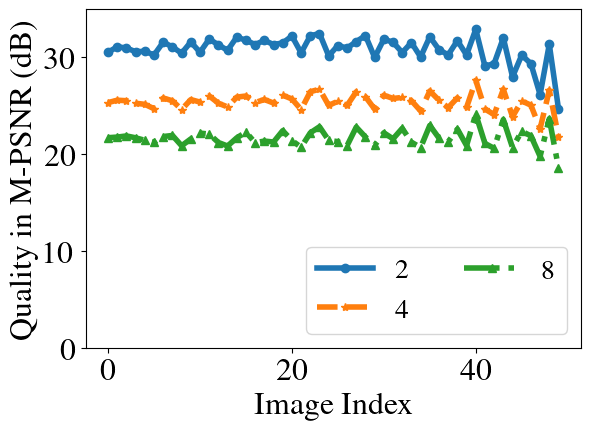

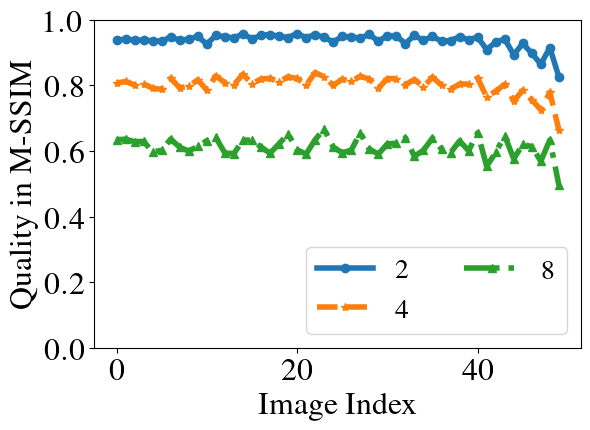

In [6]:
def uniform_gs_res_in_diff_cam_idx_distortion():
    # saveDir = Path(".")/"figs"/f"gs_res_in_diff_cam_idx_distortion_bar_plot"
    # saveDir.mkdir(parents=True, exist_ok=True)
    
    scene_name = "lego"
    exp_name = "uniform_distortion"
    gs_res_list = [2, 4, 8]
    cam_dist_list = [1]
    # cam_dist_list = [1, 2, 4, 8]
    
    # Metrics: SSIM, PSNR, MASKED_PSNR, LPIPS, LOSS, MASKED_LOSS
    METRICS_LIST = ["SSIM", "MASKED_SSIM", 
                    "PSNR", "MASKED_PSNR", 
                    "LPIPS", 
                    "LOSS", "MASKED_LOSS",
                    ]
    
    data_list = []
    
    for gs_res in gs_res_list:
        for cam_dist in cam_dist_list:
            if gs_res < cam_dist:
                render_factor = 1
            else:
                # Bash 的除法本身就是 int()，會自動捨去小數
                render_factor = gs_res // cam_dist
                
            # file_path = Path(f"/home/syjintw/Desktop/NUS/lapisgs-output/{scene_name}_old/opacity")/f"{scene_name}_res{gs_res}"/f"results_ours_{cam_dist}x_factor{render_factor}.json"
            file_path = Path(f"/home/syjintw/Desktop/NUS/lapisgs-output/{scene_name}/opacity")/f"{scene_name}_res{gs_res}"/f"results_{exp_name}"/f"per_view_ours_uniform_{cam_dist}x.json"
            with open(file_path, "r") as f:
                data = json.load(f)
                
                for image_name in data["ours_30000"]["SSIM"].keys():
                    # Iterate through items (handles cases where one file has multiple experiments)
                    l = [scene_name, int(image_name.split(".")[0]), gs_res, render_factor, cam_dist]
                    for METRICS_NAME in METRICS_LIST:
                        l.append(data["ours_30000"][METRICS_NAME][image_name])
                    data_list.append(l)
    print(data_list)
    column_names = ["scene", "image_idx", "gs_res", "render_factor", "cam_dist"] + METRICS_LIST
    df = pd.DataFrame(data_list, columns=column_names)
    
    # Step 1: change to plotting format and filter
    df_plot = df.copy()
    # df_plot['encode_size'] = df_plot['encode_size'] * 8 / df_plot['numOf3DGS']
    # df_plot['alg'] = df_plot['alg'].replace(['draco'], 'DRACO')
    
    # df_plot['scene_name'] = df_plot['scene_name'].replace(['drjohnson'], 'DJ')
    # df_plot['scene_name'] = df_plot['scene_name'].replace(['playroom'], 'PR')
    # df_plot['scene_name'] = df_plot['scene_name'].replace(['train'], 'Train')
    # df_plot['scene_name'] = df_plot['scene_name'].replace(['truck'], 'Truck')
    
    # ---------------------------------------------------------------------------- #
    #                                   Plotting                                   #
    # ---------------------------------------------------------------------------- #
    plt.figure(figsize=figsize)

    # -------------------------------- MASKED_PSNR ------------------------------- #
    x_name = 'image_idx'
    y_name = 'MASKED_PSNR'
    hue_name = 'gs_res'

    hue_list = df_plot[hue_name].unique()
    
    plt.figure(figsize=figsize)
    
    # Plot each group (hue)
    for idx, hue_val in enumerate(hue_list):
        # Filter data for this group
        subset = df_plot[df_plot[hue_name] == hue_val].sort_values(x_name)
        
        x = subset[x_name]
        y = subset[y_name]
        
        # # Calculate 95% CI bounds (Mean +/- 1.96 * Std)
        # yerr = 1.96 * y_std
        
        plt.errorbar(
            x, y, 
            yerr=None, 
            label=f'{hue_val}', # label for legend
            marker=markers[idx], markersize=6,
            linestyle=linestyles[idx], linewidth=4, 
            elinewidth=err_lw, capthick=err_capthick, capsize=err_capsize,  # Adds the little cross-bars at the ends
            color=color_palette[idx], alpha=1.0
        )
    
    # Formatting
    # plt.title(r'PSNR vs Distance by gs\_res (with 95\% CI)') # Usually, we don't write title for figures in papers
    plt.xlabel('Image Index')
    plt.ylabel('Quality in M-PSNR (dB)')
    plt.legend(title='', loc='lower right', fontsize="20", ncol=2, markerscale=1)
    
    # plt.xlim(0, 10)
    # plt.xticks([0, 5, 10])
    plt.ylim(0, 35)
    # plt.yticks([0, 10, 20, 30, 40, 50])
    
    # plt.grid(True, linestyle='--', alpha=0.6) # Personlly, don't like grid in paper figures
    plt.tight_layout()
    # plt.savefig(f'{saveDir}/compression_size_scene.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{saveDir}/compression_size_scene.eps', dpi=300, bbox_inches='tight')
    plt.show()
    
    
    # -------------------------------- MASKED_SSIM ------------------------------- #
    x_name = 'image_idx'
    y_name = 'MASKED_SSIM'
    hue_name = 'gs_res'

    hue_list = df_plot[hue_name].unique()
    
    plt.figure(figsize=figsize)
    
    # Plot each group (hue)
    for idx, hue_val in enumerate(hue_list):
        # Filter data for this group
        subset = df_plot[df_plot[hue_name] == hue_val].sort_values(x_name)
        
        x = subset[x_name]
        y = subset[y_name]
        
        # # Calculate 95% CI bounds (Mean +/- 1.96 * Std)
        # yerr = 1.96 * y_std
        
        plt.errorbar(
            x, y, 
            yerr=None, 
            label=f'{hue_val}', # label for legend
            marker=markers[idx], markersize=6,
            linestyle=linestyles[idx], linewidth=4, 
            elinewidth=err_lw, capthick=err_capthick, capsize=err_capsize,  # Adds the little cross-bars at the ends
            color=color_palette[idx], alpha=1.0
        )
    
    # Formatting
    # plt.title(r'PSNR vs Distance by gs\_res (with 95\% CI)') # Usually, we don't write title for figures in papers
    plt.xlabel('Image Index')
    plt.ylabel('Quality in M-SSIM')
    plt.legend(title='', loc='lower right', fontsize="20", ncol=2, markerscale=1)
    
    # plt.xlim(0, 10)
    # plt.xticks([0, 5, 10])
    plt.ylim(0, 1)
    # plt.yticks([0, 10, 20, 30, 40, 50])
    
    # plt.grid(True, linestyle='--', alpha=0.6) # Personlly, don't like grid in paper figures
    plt.tight_layout()
    # plt.savefig(f'{saveDir}/compression_size_scene.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{saveDir}/compression_size_scene.eps', dpi=300, bbox_inches='tight')
    plt.show()
    

uniform_gs_res_in_diff_cam_idx_distortion()

In [17]:
def load_data(quality_json_path, transforms_json_path, metric_name):
    # 1. 讀取品質數據
    with open(quality_json_path, 'r') as f:
        quality_data = json.load(f)
    
    
    metrics_map = quality_data["ours_30000"][metric_name]
    
    # 2. 讀取相機數據 (含有經緯度)
    with open(transforms_json_path, 'r') as f:
        transforms_data = json.load(f)

    lats, lons, values = [], [], []

    print(f"Loading {metric_name} data...")

    # 3. 資料對齊 (Matching)
    # 我們需要將 transforms.json 中的 frame 與 quality.json 中的 png 檔名對應起來
    # 假設 transforms 裡的 file_path 格式如 "r_0", "r_1"... 
    # 而 quality 裡的 key 格式如 "00000.png", "00001.png"...
    
    for frame in transforms_data['frames']:
        # 取得經緯度
        if 'latitude' not in frame or 'longitude' not in frame:
            continue
            
        lat = frame['latitude']
        lon = frame['longitude']
        
        # 解析 Frame ID
        # 假設 file_path 是 ".../r_15" -> 取得 15
        try:
            file_path = frame['file_path']
            frame_idx = int(file_path.split('_')[-1])
        except ValueError:
            continue

        # 格式化成 quality json 的 key 格式 (5位數補零 + .png)
        quality_key = f"{frame_idx:05d}.png"
        
        if quality_key in metrics_map:
            val = metrics_map[quality_key]
            
            lats.append(lat)
            lons.append(lon)
            values.append(val)
        else:
            print(f"Warning: Quality data for {quality_key} not found.")

    return np.array(lons), np.array(lats), np.array(values)


Loading MASKED_PSNR data...


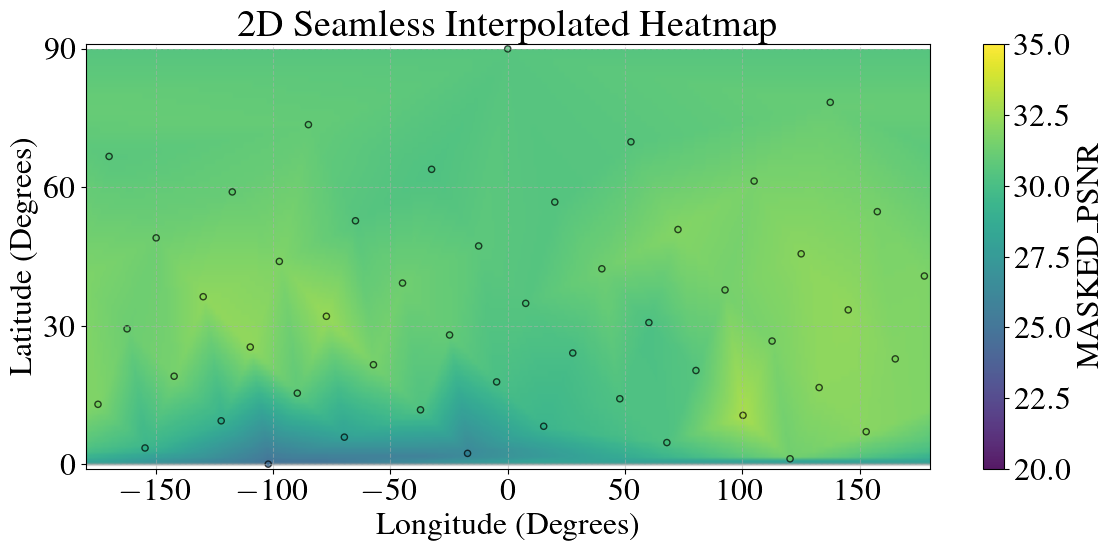

In [46]:
def plot_heatmap():
    scene_name = "lego"
    exp_name = "uniform_distortion"
    gs_res = 2
    cam_dist = 1
    
    # Metrics: SSIM, PSNR, MASKED_PSNR, LPIPS, LOSS, MASKED_LOSS
    METRICS_LIST = ["SSIM", "MASKED_SSIM", 
                    "PSNR", "MASKED_PSNR", 
                    "LPIPS", 
                    "LOSS", "MASKED_LOSS",
                    ]
    metric_idx = 3
    
    # MIN_VAL= 0.5
    # MAX_VAL= 1.0
    MIN_VAL= 20.0
    MAX_VAL= 35.0
    
    lons, lats, values = load_data(
        quality_json_path=Path(f"/home/syjintw/Desktop/NUS/lapisgs-output/{scene_name}/opacity/{scene_name}_res{gs_res}/results_{exp_name}/per_view_ours_uniform_{cam_dist}x.json"),
        transforms_json_path=Path(f"/home/syjintw/Desktop/NUS/tmp/{scene_name}/uniform_{cam_dist}x/transforms.json"),
        metric_name=METRICS_LIST[metric_idx]
        )
    
    if len(values) == 0:
        print("No matched data found to plot.")
        return

    plt.figure(figsize=(12, 6))

    # 1. 數據填充：將數據在左右各複製一份，模擬地球的循環
    lons_padded = np.concatenate([lons, lons - 360, lons + 360])
    lats_padded = np.concatenate([lats, lats, lats])
    values_padded = np.concatenate([values, values, values])

    # 2. 建立網格
    grid_lon, grid_lat = np.mgrid[-180:180:300j, -90:90:150j]
    
    # 3. 插值 (使用 'linear' 避免過度擬合產生的奇怪波紋)
    grid_z = griddata((lons_padded, lats_padded), values_padded, 
                  (grid_lon, grid_lat), method='linear')

    plt.imshow(grid_z.T, extent=(-180, 180, -90, 90), origin='lower', 
           cmap='viridis', alpha=0.9, aspect='auto',
           vmin=MIN_VAL, vmax=MAX_VAL)
    plt.colorbar(label=f'{METRICS_LIST[metric_idx]}')
    plt.scatter(lons, lats, c=values, cmap='viridis',
                edgecolors='black',
                s=20, alpha=0.7,
                vmin=MIN_VAL, vmax=MAX_VAL) # 標示原始點位
    
    # 標示軸與標題
    plt.title(f'2D Seamless Interpolated Heatmap')
    plt.xlabel('Longitude (Degrees)')
    plt.ylabel('Latitude (Degrees)')
    plt.xlim(-180, 180)
    plt.ylim(-1, 91)
    plt.yticks([0, 30, 60, 90])
    plt.grid(True, linestyle='--', alpha=0.5)

    # # 標示極值
    # max_idx = np.argmax(values)
    # min_idx = np.argmin(values)
    # plt.annotate(f'Max: {values[max_idx]:.2f}', (lons[max_idx], lats[max_idx]), 
    #              xytext=(5, 5), textcoords='offset points', color='red', fontweight='bold')
    # plt.annotate(f'Min: {values[min_idx]:.2f}', (lons[min_idx], lats[min_idx]), 
    #              xytext=(5, -15), textcoords='offset points', color='blue', fontweight='bold')

    plt.tight_layout()
    plt.show()
    
plot_heatmap()
    